## Module_3:

## Team Members:
Conner Looney and Jack Marchesi

## Project Title:
Pulmonary fibrosis and Data Interpolation



## Project Goal:
This project seeks to gain a better understanding of the symptoms, mechanisms, and treatments for firbrosis while developing interpolation skills by analyzing a set of data/images.

## Disease Background: 

**Prevalence & Incidence:**

Globally, Idiopathic Pulmonary Fibrosis (IPF) has an incidence of 5.8 per 100,000 and a prevalence of 17.7 according to an article in PubMed. In North America the incidence is 9 per 100,000 and the prevalence is 27.2 per 100,000, both of which are higher than the global averages [1].


**Risk Factors (genetic, lifestyle)**

Some of the risk factors for IPF are genetic, such as those predisposed to alveolar instability, early cell senescence, altered host defence, and cell-cell adhesion. Additionally, there is a higher prevalence of IPF in males, as they represent around 70% of IPF cases. Aging is also a major factor, as both incidence and prevalence increase with aging. Importantly, smoking and vaping contribute to the development of IPF, as do wood dust, metal dust, and sand [2].

**Symptoms**

Shortness of breath, dry coughing, unintended weight loss, tiredness, aching joints and muscles, and clubbing of the fingers and toes are symptoms of IPF, according to the Mayo Clinic [3].

**Standard of Care Treatment(s)**

There is currently no cure for IPF but there are treatments. The most prevalent forms of treatment are antifibrotic drugs such as pirfenidone or nintedanib. Bilateral lung transplants are also an effective option [4]. Patients with IPF pay an average of over $10,000 annually [5].

**Biological Mechanisms (anatomy, organ physiology, cell & molecular physiology)**

Damage to the alveolar epithelial cells (in the lungs) is believed to be an important factor in the development of fibrosis. This leads to an excess of myofibroblasts aiming to help repair the damage. The excess of myofibroblasts leads to an excess of collagen, leading to scarring on the lungs. While the mechanisms of IPF aren’t fully understood these concepts are believed to be a potential basis.[6]

**Diagnosis**

IPF can be diagnosed in a number of ways with a number of tests, including tissue or blood samples, lung function tests, and imaging tests. Imaging tests include CT, X-Ray, and Echocardiogram scans which look for lung damage, tissue scaring, and even arterial pressure. Lung function tests look at aspects such as  volume and diffusion. Blood tests look at the function of the liver and kidney. Tissue samples include biopsies aimed to get an actual sample of the lungs to examine scar tissue and other related symptoms [8].

## Data-Set: 
We were given a set of 78 images, taken from varying depths in a mouse's lung. The lung represented pulmonary fibrotic tissue, and was obtained via the research described below.

The Peirce-Cottler Lab working with the Kim Lab at the University of Virginia School of Medicine produced a Bleomycin-induced lung injury model.
1. A mouse was injected with Bleomycin (a pulmonary fibrosis inducing medicine), and will develop pulmonary fibrosis over a three week period. 
2. The mouse is then sacrificed for research and the lungs are harvested. 
3. Paraformaldehyde, a crystalline polymer, was used to fix the lung, and the lung was then placed in a wax/gel.
4. The lung was sliced into thin pieces at known depths (in microns), and stained by a fluorescent antibody to be viewed under a microscope.
5. Desmin, an antibody used to mark myofibroblasts, helped create black and white images of fibrotic vs non-fibrotic areas of the tissue.


Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 


## Data Analyis: 

* Methods:

1. Starting with the set of images taken from the lung of a mouse, we randomly chose 9 images, and imported them into our original_main python file, while also prescribing known depths at which those images were taken
2. For each image, we used python's cv2 module to analyze the percentage of white pixels, showing fibrotic tissue within the lung
3. We tested the interpolate function, using a random depth that was not known from an image.
4. After confirming the validity of the interpolate function, we chose three separate depths that had known images. We interpolated using the interp1d module both linearly and quadratically at these depths, without analyzing the white pixel percentages of the known images.
5. We then used the cv2 module to read the three images, and obtained white pixel percentages for the images.
6. We used the known white pixel percentages to calculate the percent error of interpolation, both linearly and quadratically.
7. We calculated the averages of these errors for the interpolated data points and compared them against one another.

Counts of pixel color in each image
C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010021.jpg

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010021.jpg:
White pixels: 23900
Black pixels: 4170404
0.57% White | Depth: 30 microns
C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010030.jpg

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010030.jpg:
White pixels: 37799
Black pixels: 4156505
0.90% White | Depth: 200 microns
C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010051.jpg

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010051.jpg:
White pixels: 43424
Black pixels: 4150880
1.04% White | Depth: 400 microns
C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\M

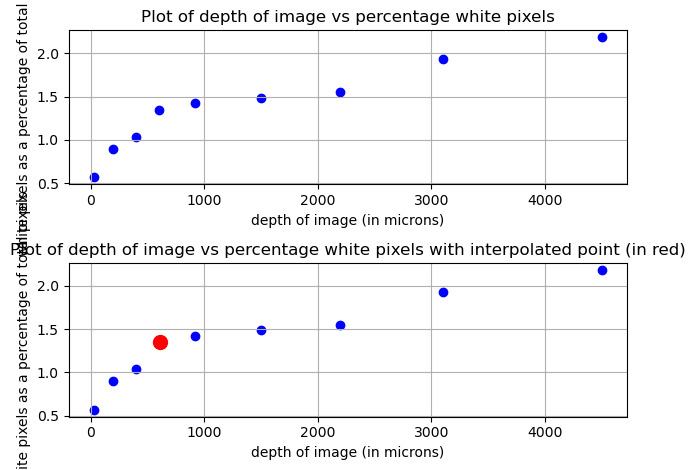

In [4]:
#AI Usage Statement: AI was used to help debug and increase efficiency

from termcolor import colored
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
import cv2
import numpy as np
import pandas as pd
import time

start_time = time.time()

filenames = [r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010021.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010030.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010051.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010024.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Slobe ch010158.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010067.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010164.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010174.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Slobe ch010134.jpg",
             ]
""""
filenames = [
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010021.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010030.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010051.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010024.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Slobe ch010158.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010067.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010164.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010174.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Slobe ch010134.jpg",
]
"""

depths = [30, 200, 400, 600, 920, 1500, 2200, 3100, 4500]

white_percents = []

print(colored("Counts of pixel color in each image", "yellow"))

for filename, depth in zip(filenames, depths):
    print(filename)
    img = cv2.imread(filename, 0)

    #if img is None:
     #   print(f"Error loading image: {filename}")
      #  continue

    # Threshold
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Count pixels efficiently
    white = np.count_nonzero(binary == 255)
    total = binary.size
    black = total - white

    # Compute percent
    white_percent = 100 * white / total
    white_percents.append(white_percent)

    # Print (same style as before)
    print(colored(f"\n{filename}:", "red"))
    print(colored(f"White pixels: {white}", "white"))
    print(colored(f"Black pixels: {black}", "grey"))
    print(f"{white_percent:.2f}% White | Depth: {depth} microns")

# Create DataFrame (UNCHANGED STRUCTURE)
df = pd.DataFrame({
    'Filenames': filenames,
    'Depths': depths,
    'White percents': white_percents
})

# Save CSV (same as before)
df.to_csv('Percent_White_Pixels.csv', index=False)

print("\nThe .csv file 'Percent_White_Pixels.csv' has been created.")


end_time = time.time()
print(f"\nExecution time: {end_time - start_time:.4f} seconds")


# LECTURE 2: UNCOMMENT BELOW

# # Interpolate a point: given a depth, find the corresponding white pixel percentage

interpolate_depth = float(input(colored(
     "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

x = depths
y = white_percents

 # You can also use 'quadratic', 'cubic', etc.
i = interp1d(x, y, kind='quadratic')
interpolate_point = i(interpolate_depth)
print(colored(
    f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# # make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a percentage of total pixels')
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
               linestyle='-', color='blue')
axs[1].set_title(
    'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a percentage of total pixels')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
               color='red', s=100, label='Highlighted point')


# # Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


This graph shows the first interpolation prediction using quadratic interpolation, not used in our final set of predictions but used to show the concept of interpolation. It also includes the known data points marked in blue.

Counts of pixel color in each image

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010021.jpg:
White pixels: 23900
Black pixels: 4170404
0.57% White | Depth: 30 microns

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010030.jpg:
White pixels: 37799
Black pixels: 4156505
0.90% White | Depth: 200 microns

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010051.jpg:
White pixels: 43424
Black pixels: 4150880
1.04% White | Depth: 400 microns

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010024.jpg:
White pixels: 56360
Black pixels: 4137944
1.34% White | Depth: 600 microns

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Slobe ch010158.jpg:
White pixels: 59788
Black pixels: 4134516
1.43% White | Depth: 920 microns

C:\Users\Jmarc\Desktop\Comp BME\mo

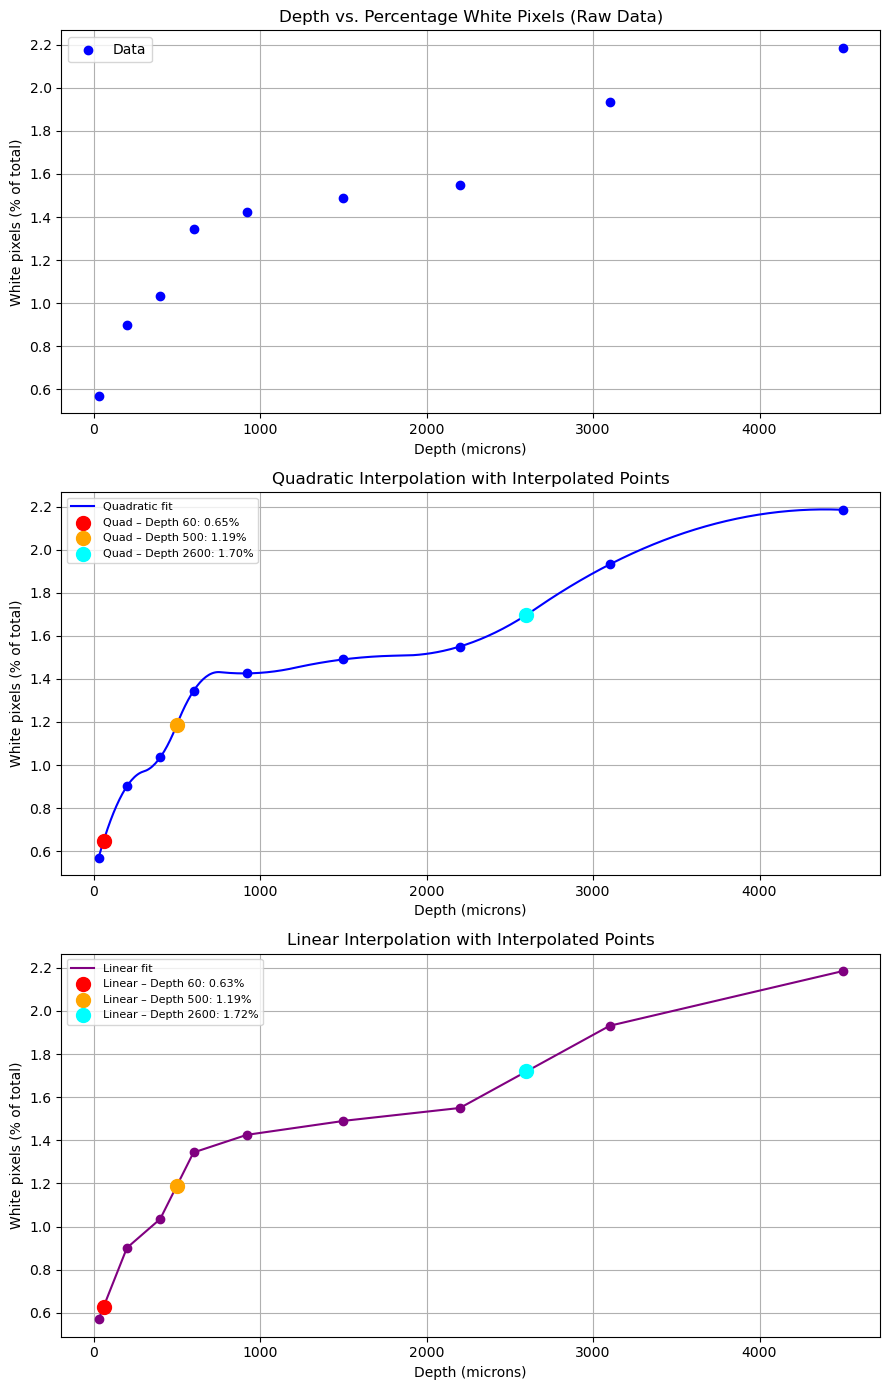


C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010019.jpg:
White pixels: 31331
Black pixels: 4162973
0.75% White | Depth: 60 microns

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010032.jpg:
White pixels: 48667
Black pixels: 4145637
1.16% White | Depth: 500 microns

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010143.jpg:
White pixels: 70715
Black pixels: 4123589
1.69% White | Depth: 2600 microns

--- Percent Error vs. Ground Truth ---
Label              Depth      Actual        Quad   Quad Err%      Linear    Lin Err%
--------------------------------------------------------------------------------
Depth 60              60      0.7470      0.6479      13.26%      0.6283      15.89%
Depth 500            500      1.1603      1.1874       2.33%      1.1895       2.52%
Depth 2600          2600      1.6860      1.6972       0.67%      

In [3]:
#AI Usage Statement: AI was used to help debug and increase efficiency, as well as the plot functions

from termcolor import colored
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
import cv2
import numpy as np
import pandas as pd
import time


start_time = time.time()

filenames = [r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010021.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010030.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010051.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010024.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Slobe ch010158.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010067.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010164.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010174.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Slobe ch010134.jpg",
             ]

# the depth in microns that each image was taken at
depths = [30, 200, 400, 600, 920, 1500, 2200, 3100, 4500]

# empty list to store the white pixel percentages as we calculate them
white_percents = []

print(colored("Counts of pixel color in each image", "yellow"))

# loop through each image and its corresponding depth at the same time
for filename, depth in zip(filenames, depths):
    # read the image in grayscale (0 flag = grayscale)
    img = cv2.imread(filename, 0)

    # convert grayscale to pure black and white using a threshold of 127
    # anything above 127 becomes 255 (white), anything below becomes 0 (black)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # count the number of white pixels (value = 255)
    white = np.count_nonzero(binary == 255)
    # .size gives total number of pixels (rows * cols), NOT just rows
    total = binary.size
    # everything that isnt white must be black
    black = total - white

    # calculate what percent of the image is white
    white_percent = 100 * white / total
    white_percents.append(white_percent)

    # print the results for this image
    print(colored(f"\n{filename}:", "red"))
    print(colored(f"White pixels: {white}", "white"))
    print(colored(f"Black pixels: {black}", "grey"))
    print(f"{white_percent:.2f}% White | Depth: {depth} microns")

# store everything in a dataframe so we can save it as a csv
df = pd.DataFrame({
    'Filenames': filenames,
    'Depths': depths,
    'White percents': white_percents
})

# save the dataframe to a csv file
df.to_csv('Percent_White_Pixels.csv', index=False)
print("\nThe .csv file 'Percent_White_Pixels.csv' has been created.")

# stop the timer and print how long everything took
end_time = time.time()
print(f"\nExecution time: {end_time - start_time:.4f} seconds")

# Interpolation 

x = depths
y = white_percents

# create two interpolation functions using scipy - one quadratic, one linear
# these let us estimate white % at depths we didnt actually image
i_quadratic = interp1d(x, y, kind='quadratic')
i_linear    = interp1d(x, y, kind='linear')

# these are the three depths we want to predict - they match our ground truth images
query_depths = [60, 500, 2600]
query_labels = ['Depth 60', 'Depth 500', 'Depth 2600']

# run each "query" depth through both interpolators
quad_points   = [float(i_quadratic(d)) for d in query_depths]
linear_points = [float(i_linear(d))    for d in query_depths]

# print a nicely formatted table comparing the two methods
print(colored("\n--- Interpolation Results ---", "yellow"))
print(f"{'Label':<15} {'Depth':>8}  {'Quadratic':>12}  {'Linear':>12}")
print("-" * 52)
for lbl, d, q, l in zip(query_labels, query_depths, quad_points, linear_points):
    print(colored(f"{lbl:<15} {d:>8.1f}  {q:>12.4f}  {l:>12.4f}", "green"))

# Plots are below - they show the original data points, the interpolation curves, and the interpolated points for visual comparison

# generate 500 evenly spaced depth values across our range for smooth curve plotting
depth_smooth = np.linspace(min(x), max(x), 500)
curve_quad   = i_quadratic(depth_smooth)
curve_linear = i_linear(depth_smooth)

# colors for the interpolated points on the plots
point_colors = ['red', 'orange', 'cyan']

# 3 subplots stacked vertically
fig, axs = plt.subplots(3, 1, figsize=(9, 14))

# Plot 1: just the raw data, no interpolation ---
axs[0].scatter(x, y, marker='o', color='blue', zorder=5, label='Data')
axs[0].set_title('Depth vs. Percentage White Pixels (Raw Data)')
axs[0].set_xlabel('Depth (microns)')
axs[0].set_ylabel('White pixels (% of total)')
axs[0].grid(True)
axs[0].legend()

# Plot 2: quadratic curve + the interpolated points highlighted ---
axs[1].plot(depth_smooth, curve_quad, color='blue', linewidth=1.5, label='Quadratic fit')
axs[1].scatter(x, y, marker='o', color='blue', zorder=5)
for d, p, lbl, col in zip(query_depths, quad_points, query_labels, point_colors):
    axs[1].scatter(d, p, color=col, s=100, zorder=6, label=f'Quad – {lbl}: {p:.2f}%')
axs[1].set_title('Quadratic Interpolation with Interpolated Points')
axs[1].set_xlabel('Depth (microns)')
axs[1].set_ylabel('White pixels (% of total)')
axs[1].grid(True)
axs[1].legend(fontsize=8)

# --- Plot 3: linear curve + the interpolated points highlighted ---
axs[2].plot(depth_smooth, curve_linear, color='purple', linewidth=1.5, label='Linear fit')
axs[2].scatter(x, y, marker='o', color='purple', zorder=5)
for d, p, lbl, col in zip(query_depths, linear_points, query_labels, point_colors):
    axs[2].scatter(d, p, color=col, s=100, zorder=6, label=f'Linear – {lbl}: {p:.2f}%')
axs[2].set_title('Linear Interpolation with Interpolated Points')
axs[2].set_xlabel('Depth (microns)')
axs[2].set_ylabel('White pixels (% of total)')
axs[2].grid(True)
axs[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Verification of interpolation accuracy using true images
# these are the actual images taken at the depths we interpolated above
# we use them to check how accurate our interpolations were

after_filenames = [r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010019.jpg",
                   r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010032.jpg",
                   r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010143.jpg"]

after_depths = [60, 500, 2600]
after_white_percents = []

# Same pixel counting process as before, just for the after images
for filename, depth in zip(after_filenames, after_depths):
    img = cv2.imread(filename, 0)

    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    white = np.count_nonzero(binary == 255)
    total = binary.size
    black = total - white

    white_percent = 100 * white / total
    after_white_percents.append(white_percent)

    print(colored(f"\n{filename}:", "red"))
    print(colored(f"White pixels: {white}", "white"))
    print(colored(f"Black pixels: {black}", "grey"))
    print(f"{white_percent:.2f}% White | Depth: {depth} microns")

# Percent Error calculations
# percent error formula: |predicted - actual| / actual * 100
# this tells us how far off each interpolation method was from the real image

print(colored("\n--- Percent Error vs. Ground Truth ---", "yellow"))
print(f"{'Label':<15} {'Depth':>8}  {'Actual':>10}  {'Quad':>10}  {'Quad Err%':>10}  {'Linear':>10}  {'Lin Err%':>10}")
print("-" * 80)

quad_errors   = []
linear_errors = []

for lbl, d, actual, q, l in zip(query_labels, after_depths, after_white_percents, quad_points, linear_points):
    quad_err   = abs(q - actual) / actual * 100
    linear_err = abs(l - actual) / actual * 100
    quad_errors.append(quad_err)
    linear_errors.append(linear_err)
    print(colored(
        f"{lbl:<15} {d:>8}  {actual:>10.4f}  {q:>10.4f}  {quad_err:>9.2f}%  {l:>10.4f}  {linear_err:>9.2f}%",
        "green"))

# print the average error for each method so we can compare them overall
print("-" * 80)
print(colored(
    f"{'Mean Error':<15} {'':>8}  {'':>10}  {'':>10}  {np.mean(quad_errors):>9.2f}%  {'':>10}  {np.mean(linear_errors):>9.2f}%",
    "cyan"))

These graphs show our interpolated data points, along with the known/used data points. We show both linear and quadratic interpolation, with curves to show the quadratic lines as well as the linear lines.

## Verification: 

Percent error of each interpolated data point:

|Predicted white pixel percentage - Actual white pixel percentage|/Actual white pixel percentage

* Interpolation at 60 microns depth: 
    * Linear: 0.6283% white pixels
        * 15.89% error
    * Quadratic: 0.6479% white pixels
        * 13.26% error
* Interpolation at 500 microns depth:
    * Linear: 1.1895% white pixels 
        * 2.52% error
    * Quadratic: 1.1874% white pixels
        * 2.33% error
* Interpolation at 2600 microns depth:
    * Linear: 1.7197% white pixels
        * 2.00% error
    * Quadratic: 1.6972% white pixels
        * 0.67% error


In our pulmonary fibrosis analysis and prediction interpolation, we found a mean error of 5.42% for our quadratic interpolations, and a mean error of 6.80% for our linear interpolations. This shows a slight favorability of quadratic interpolation over linear interpolation.

* We expected to see the favorability to quadratic interpolation in this data set, mainly because the images we analyzed showed a concave down quadratic trend.

# Validation:



## Conclusions and Ethical Implications: 

After running our code we concluded that our interpolation based on a quadratic fit was best suited for this data set, suggesting that fibrosis in the lungs increases with depth (at least for these mice) in a quadratic manner. It’s important to realize that the data doesn’t come from humans so it shouldn't necessarily be used as a model for human lungs. Also, while our quadratic interpolation did yield an error of only 5.42% it’s important to realize that the error is very real and shouldn’t necessarily be used as a basis for treatment/cure research going forward, merely as a means for showing an overall trend. To claim this work as a standard for all future research could ethically (although unintentionally) lead the field astray from more accurate results that could lead to a cure. 

## Limitations and Future Work: 
We were in part limited by the amount of data we had in our set, and the number of data sets we had. To gain a better understanding of the accuracy of interpolation with different data fits, it would be helpful to have access to more sets of data with relatively clear fits (linear, quadratic, cubic) and some with seemingly no fit to learn the advantages and limitations of interpolation. Also, it would be interesting to look at data for humans, not just for mice, as the conclusions we drew about our data may vary from species to species. 

For future work, we would love to look into InterpolAi, an artificial intelligence trained to interpolate images themselves, and to help build 3D images of tissue. InterpolAi uses optical flow based deep learning to construct the missing portions of 3D images between 2D section images. This maintains the cell structures and mircobiology within the sectioned tissues, while creating a 3D image that can be used for more advanced testing. Additionally, this decreases the number of images needed to create models, based on current imaging techniques. In terms of fibrosis, it would be intruiging to see the lung tissue reconstruction of fibrosis patients vs healthy patients, and compare the resistance of expansion of the lung via volumetric calculations.

Additionally, we'd like to look into the specifics of how fibrosis can spread unevenly throughout a mouse's lung, and if this characteristic is consistent with human lungs. We saw a positive correlation between the depth of the image and amount of fibrotic tissue. In vivo experiments that limit ventilation in certain area of the lung could lead to a compelling study behind ventilation rates and progression of pulmonary fibrosis.

## References:

Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine.

1.
Golchin, N., Patel, A., Scheuring, J., Wan, V., Hofer, K., Collet, J. P., Elpers, B., & Lesperance, T. (2025). Incidence and prevalence of idiopathic pulmonary fibrosis: a systematic literature review and meta-analysis. BMC pulmonary medicine, 25(1), 378. https://doi.org/10.1186/s12890-025-03836-1

2.
Zaman, T., & Lee, J. S. (2018). Risk factors for the development of idiopathic pulmonary fibrosis: A review. Current pulmonology reports, 7(4), 118–125. https://doi.org/10.1007/s13665-018-0210-7 

3.
Mayo Clinic. “Pulmonary Fibrosis - Symptoms and Causes.” Mayo Clinic, 2018, www.mayoclinic.org/diseases-conditions/pulmonary-fibrosis/symptoms-causes/syc-20353690. Accessed 2 Apr. 2026.

4.
Glass, D. S., Grossfeld, D., Renna, H. A., Agarwala, P., Spiegler, P., DeLeon, J., & Reiss, A. B. (2022). Idiopathic pulmonary fibrosis: Current and future treatment. The clinical respiratory journal, 16(2), 84–96. https://doi.org/10.1111/crj.13466

5.
May, Brandon. “Idiopathic Pulmonary Fibrosis Annualized Costs Totals More than $10,000 per Patient.” Pulmonology Advisor, 13 Feb. 2020, www.pulmonologyadvisor.com/news/idiopathic-pulmonary-fibrosis-annualized-costs-of-care-per-patient/. Accessed 3 Apr. 2026. 

6.
Spagnolo, P., Kropski, J. A., Jones, M. G., Lee, J. S., Rossi, G., Karampitsakos, T., Maher, T. M., Tzouvelekis, A., & Ryerson, C. J. (2021). Idiopathic pulmonary fibrosis: Disease mechanisms and drug development. Pharmacology & therapeutics, 222, 107798. https://doi.org/10.1016/j.pharmthera.2020.107798 

7.
InterpolAI authors. (2025). InterpolAI: Deep learning-based optical flow interpolation and restoration of biomedical images for improved 3D tissue mapping. Nature Methods. https://doi.org/10.1038/s41592-025-02712-4 

8.
Mayo Clinic Staff. “Pulmonary Fibrosis - Diagnosis and Treatment - Mayo Clinic.” Mayoclinic.org, 2018, www.mayoclinic.org/diseases-conditions/pulmonary-fibrosis/diagnosis-treatment/drc-20353695. 

